# Лабораторна робота: базовий workflow задачі класифікації

**Виконала:** студентка групи ФБ-62мп Шукалович Марія

**Мета роботи:** ознайомитися з базовим workflow задачі класифікації: від вибору та аналізу даних до навчання, налаштування, порівняння та оцінювання моделей машинного навчання з використанням бібліотеки Scikit-learn.

**Датасет:** [Predict Students' Dropout and Academic Success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) (UCI Machine Learning Repository, ліцензія CC BY 4.0). Дані про 4 424 студентів бакалаврату португальського закладу вищої освіти: інформація на момент вступу (освітній шлях, демографія, соціально-економічні фактори) та успішність наприкінці 1-го і 2-го семестрів.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() - 1)
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## Завантаження та первинний аналіз даних

Файл використовує `;` як роздільник. Одразу очищаємо назви колонок: прибираємо зайві пробіли й табуляцію (вона є в назві `Daytime/evening attendance`), скорочуємо префікс «Curricular units» і виправляємо опечатку «Nacionality».

In [2]:
df = pd.read_csv("data.csv", sep=";")
df.columns = (df.columns.str.strip()
              .str.replace("Curricular units ", "", regex=False)
              .str.replace("Nacionality", "Nationality", regex=False))
print("Розмір датасета (рядки, колонки):", df.shape)
print("Назви колонок:")
print(df.columns.tolist())
display(df.head())

Розмір датасета (рядки, колонки): (4424, 37)
Назви колонок:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', '1st sem (credited)', '1st sem (enrolled)', '1st sem (evaluations)', '1st sem (approved)', '1st sem (grade)', '1st sem (without evaluations)', '2nd sem (credited)', '2nd sem (enrolled)', '2nd sem (evaluations)', '2nd sem (approved)', '2nd sem (grade)', '2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,1st sem (credited),1st sem (enrolled),1st sem (evaluations),1st sem (approved),1st sem (grade),1st sem (without evaluations),2nd sem (credited),2nd sem (enrolled),2nd sem (evaluations),2nd sem (approved),2nd sem (grade),2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Визначаємо ознаки та цільову змінну. Хоча всі ознаки мають числовий тип, частина з них є кодами категорій (номінальними ознаками), а не величинами: наприклад, значення `Course` 9500 чи 171 означає лише номер спеціальності.

In [3]:
target = "Target"
class_names = ["Dropout", "Enrolled", "Graduate"]
nominal_cols = ["Marital status", "Application mode", "Course", "Previous qualification", "Nationality",
                "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
binary_cols = [c for c in df.columns if c != target and df[c].nunique() == 2]
numeric_cols = [c for c in df.columns if c not in nominal_cols + binary_cols + [target]]
features = nominal_cols + binary_cols + numeric_cols
print("Кількість ознак:", len(features))
print("Номінальні (категорії, закодовані числами):", nominal_cols)
print("Бінарні (0/1):", binary_cols)
print("Числові:", numeric_cols)
print("Цільова змінна:", target, "->", class_names)

Кількість ознак: 36
Номінальні (категорії, закодовані числами): ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Бінарні (0/1): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
Числові: ['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', '1st sem (credited)', '1st sem (enrolled)', '1st sem (evaluations)', '1st sem (approved)', '1st sem (grade)', '1st sem (without evaluations)', '2nd sem (credited)', '2nd sem (enrolled)', '2nd sem (evaluations)', '2nd sem (approved)', '2nd sem (grade)', '2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
Цільова змінна: Target -> ['Dropout', 'Enrolled', 'Graduate']


Типи даних:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital status                  4424 non-null   int64  
 1   Application mode                4424 non-null   int64  
 2   Application order               4424 non-null   int64  
 3   Course                          4424 non-null   int64  
 4   Daytime/evening attendance      4424 non-null   int64  
 5   Previous qualification          4424 non-null   int64  
 6   Previous qualification (grade)  4424 non-null   float64
 7   Nationality                     4424 non-null   int64  
 8   Mother's qualification          4424 non-null   int64  
 9   Father's qualification          4424 non-null   int64  
 10  Mother's occupation             4424 non-null   int64  
 11  Father's occupation             4424 non-null   int64  
 12  Admission grade                 44

Розподіл об'єктів за класами:

,Кількість,Частка
Target,,
Dropout,1421,0.321
Enrolled,794,0.179
Graduate,2209,0.499


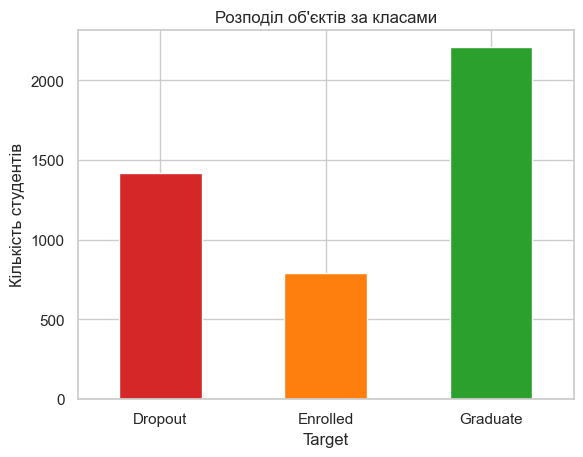

In [5]:
class_counts = df[target].value_counts().reindex(class_names)
display(pd.DataFrame({"Кількість": class_counts, "Частка": (class_counts / len(df)).round(3)}))
class_counts.plot(kind="bar", color=["tab:red", "tab:orange", "tab:green"], rot=0)
plt.title("Розподіл об'єктів за класами")
plt.ylabel("Кількість студентів")
plt.show()

Датасет містить 4 424 рядки і 37 колонок: 36 ознак і цільову змінну `Target`. Усі ознаки мають числовий тип (`int64` або `float64`), але за змістом їх можна поділити на три групи: 9 номінальних (коди категорій: сімейний стан, спосіб вступу, спеціальність, попередня освіта, громадянство, освіта й професії батьків), 8 бінарних (значення 0 або 1) і 19 числових (оцінки, вік, кількість дисциплін за семестрами, макроекономічні показники).

Задача полягає в багатокласовій класифікації: потрібно передбачити статус студента наприкінці нормативного терміну навчання, тобто Dropout (відрахований), Enrolled (ще навчається) або Graduate (випустився). Класи незбалансовані: Graduate має 2 209 студентів (49.9 %), Dropout 1 421 (32.1 %), Enrolled 794 (17.9 %). Тому, крім accuracy, орієнтуватимемося на macro F1: ця метрика однаково враховує всі класи, зокрема найменший клас Enrolled.

## Попередня обробка даних

Перевірка пропусків, дублікатів, діапазонів числових ознак і кількості кодів у номінальних ознаках:

In [6]:
print("Пропущених значень:", df.isna().sum().sum())
print("Повних дублікатів:", df.duplicated().sum())
display(df[numeric_cols].describe().T.round(2))
display(pd.DataFrame({
    "Кількість кодів": df[nominal_cols].nunique(),
    "Рідкісних кодів (< 1% рядків)": [(df[c].value_counts() < 0.01 * len(df)).sum() for c in nominal_cols],
}))

Пропущених значень: 0
Повних дублікатів: 0


,count,mean,std,min,25%,50%,75%,max
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age at enrollment,4424.0,23.27,7.59,17.00,19.00,20.00,25.00,70.00
1st sem (credited),4424.0,0.71,2.36,0.00,0.00,0.00,0.00,20.00
1st sem (enrolled),4424.0,6.27,2.48,0.00,5.00,6.00,7.00,26.00
1st sem (evaluations),4424.0,8.30,4.18,0.00,6.00,8.00,10.00,45.00
1st sem (approved),4424.0,4.71,3.09,0.00,3.00,5.00,6.00,26.00
1st sem (grade),4424.0,10.64,4.84,0.00,11.00,12.29,13.40,18.88
1st sem (without evaluations),4424.0,0.14,0.69,0.00,0.00,0.00,0.00,12.00


,Кількість кодів,Рідкісних кодів (< 1% рядків)
Marital status,6,3
Application mode,18,9
Course,17,1
Previous qualification,17,12
Nationality,21,20
Mother's qualification,29,21
Father's qualification,34,27
Mother's occupation,32,22
Father's occupation,46,34


Прийняті рішення щодо попередньої обробки:

- Пропусків і дублікатів немає, тому заповнювати чи видаляти нічого не потрібно (автори датасету вже виконали очищення).
- Діапазони числових ознак правдоподібні: оцінка попередньої освіти та вступна оцінка лежать у межах від 95 до 190 (шкала від 0 до 200), середні оцінки за семестр від 0 до 18.9 (шкала від 0 до 20), вік від 17 до 70 років. Тому викиди не видаляємо. Нульова оцінка за семестр означає, що студент не склав жодної дисципліни, і це важлива інформація, а не помилка.
- Номінальні ознаки записані числовими кодами. Якщо залишити їх без змін, kNN і SVM сприйматимуть код 9500 як «більший» за 171, хоча жодного порядку між спеціальностями немає. Тому застосовуємо one-hot кодування (`pd.get_dummies`). Перед цим рідкісні коди, які трапляються менш ніж в 1 % рядків (тобто менш ніж у 44 студентів), об'єднуємо в окрему категорію `-1` («інше»). Інакше з'явилися б десятки майже порожніх колонок: наприклад, у `Father's occupation` рідкісними є 34 з 46 кодів.
- Бінарні ознаки вже мають значення 0 або 1, тому їх не перекодовуємо.
- Цільову змінну кодуємо числами: Dropout = 0, Enrolled = 1, Graduate = 2.

Після кодування кількість ознак зростає з 36 до 107.

In [7]:
data = df.copy()
data[target] = data[target].map({name: i for i, name in enumerate(class_names)})
min_count = int(0.01 * len(data))
for col in nominal_cols:
    counts = data[col].value_counts()
    rare_codes = counts[counts < min_count].index
    data[col] = data[col].where(~data[col].isin(rare_codes), -1)
data_encoded = pd.get_dummies(data, columns=nominal_cols, dtype=int)
print("Ознак до кодування:", len(features), "| після one-hot:", data_encoded.shape[1] - 1)
display(data_encoded.head())

Ознак до кодування: 36 | після one-hot: 107


,Application order,Daytime/evening attendance,Previous qualification (grade),Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,1st sem (credited),1st sem (enrolled),1st sem (evaluations),1st sem (approved),1st sem (grade),1st sem (without evaluations),2nd sem (credited),2nd sem (enrolled),2nd sem (evaluations),2nd sem (approved),2nd sem (grade),2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Marital status_-1,Marital status_1,Marital status_2,Marital status_4,Application mode_-1,Application mode_1,Application mode_7,Application mode_17,Application mode_18,Application mode_39,Application mode_42,Application mode_43,Application mode_44,Application mode_51,Course_-1,Course_171,Course_8014,Course_9003,Course_9070,Course_9085,Course_9119,Course_9130,Course_9147,Course_9238,Course_9254,Course_9500,Course_9556,Course_9670,Course_9773,Course_9853,Course_9991,Previous qualification_-1,Previous qualification_1,Previous qualification_3,Previous qualification_12,Previous qualification_19,Previous qualification_39,Nationality_-1,Nationality_1,Mother's qualification_-1,Mother's qualification_1,Mother's qualification_2,Mother's qualification_3,Mother's qualification_4,Mother's qualification_19,Mother's qualification_34,Mother's qualification_37,Mother's qualification_38,Father's qualification_-1,Father's qualification_1,Father's qualification_2,Father's qualification_3,Father's qualification_19,Father's qualification_34,Father's qualification_37,Father's qualification_38,Mother's occupation_-1,Mother's occupation_0,Mother's occupation_1,Mother's occupation_2,Mother's occupation_3,Mother's occupation_4,Mother's occupation_5,Mother's occupation_6,Mother's occupation_7,Mother's occupation_9,Mother's occupation_90,Father's occupation_-1,Father's occupation_0,Father's occupation_1,Father's occupation_2,Father's occupation_3,Father's occupation_4,Father's occupation_5,Father's occupation_6,Father's occupation_7,Father's occupation_8,Father's occupation_9,Father's occupation_10,Father's occupation_90
0,5,1,122.0,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,1,160.0,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,5,1,122.0,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2,1,122.0,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,1,0,100.0,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


## Візуалізація та дослідження даних

Ознак багато (36), тому для детальних графіків обмежимося найінформативнішими. Інформативність оцінюємо за допомогою mutual information між кожною ознакою та цільовою змінною: на відміну від кореляції, ця міра враховує і нелінійні залежності, і підходить для категоріальної цільової змінної.

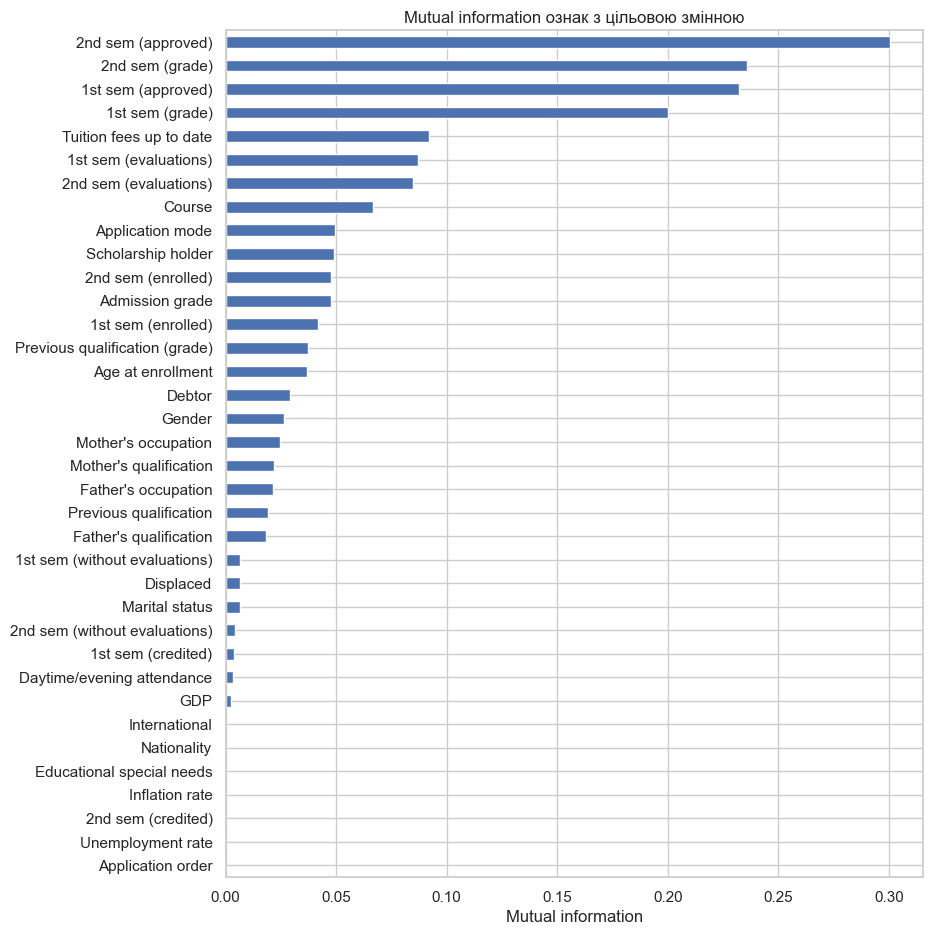

Найінформативніші числові ознаки: ['2nd sem (approved)', '2nd sem (grade)', '1st sem (approved)', '1st sem (grade)', '1st sem (evaluations)', '2nd sem (evaluations)']
Найінформативніші бінарні ознаки: ['Tuition fees up to date', 'Scholarship holder', 'Debtor', 'Gender']


In [8]:
discrete_mask = [c in nominal_cols or c in binary_cols for c in features]
mi = pd.Series(mutual_info_classif(data[features], data[target], discrete_features=discrete_mask,
                                   random_state=RANDOM_STATE), index=features).sort_values()
plt.figure(figsize=(9, 11))
mi.plot(kind="barh")
plt.title("Mutual information ознак з цільовою змінною")
plt.xlabel("Mutual information")
plt.show()
top_numeric = mi[numeric_cols].sort_values(ascending=False).index[:6].tolist()
top_binary = mi[binary_cols].sort_values(ascending=False).index[:4].tolist()
print("Найінформативніші числові ознаки:", top_numeric)
print("Найінформативніші бінарні ознаки:", top_binary)

Найбільше інформації про результат навчання несуть академічні показники: кількість складених дисциплін (approved) і середня оцінка (grade) за перший та другий семестри. Далі йдуть своєчасна оплата навчання (`Tuition fees up to date`), кількість оцінювань, спеціальність і спосіб вступу. Макроекономічні показники, громадянство, `International` і `Educational special needs` майже не пов'язані з результатом.

### Heatmap кореляцій числових ознак

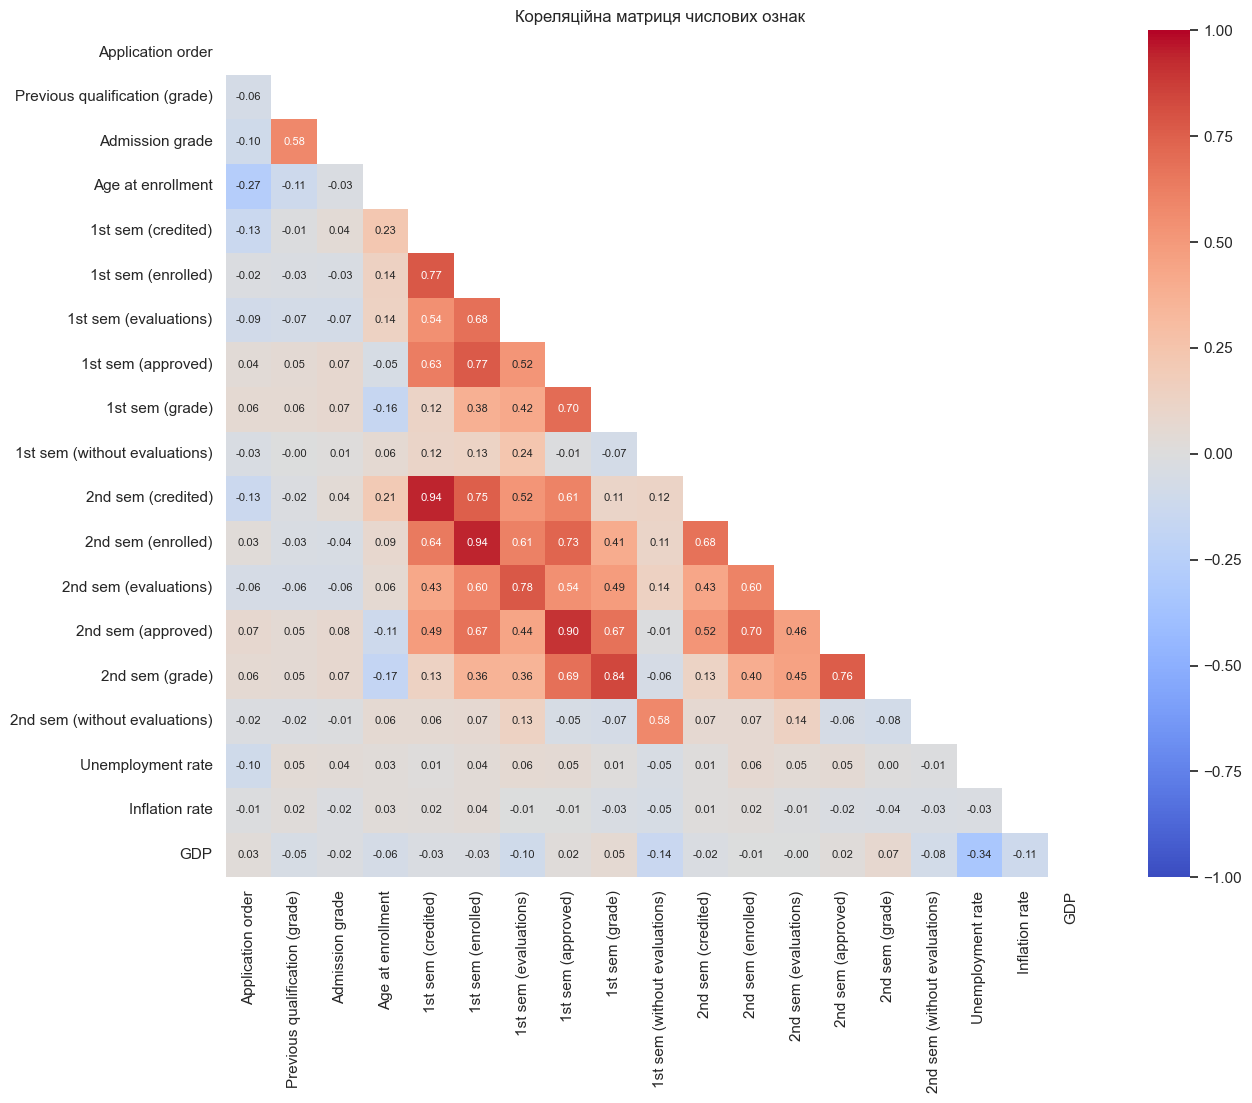

In [9]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("Кореляційна матриця числових ознак")
plt.grid(False)
plt.show()

На heatmap видно сильну кореляцію між однойменними показниками двох семестрів: для зарахованих дисциплін (credited) коефіцієнт становить 0.94, для записаних (enrolled) 0.94, для складених (approved) 0.90, для середньої оцінки (grade) 0.84. Усередині семестру кількість складених дисциплін пов'язана з оцінкою (0.70 у першому семестрі та 0.76 у другому). Отже, частина ознак дублює одна одну (мультиколінеарність), але для дерев рішень і SVM це не критично. Оцінка попередньої освіти помірно корелює зі вступною оцінкою (0.58), а макроекономічні показники практично не пов'язані з академічними.

### Гістограми та boxplot-и найінформативніших ознак відносно цільової змінної

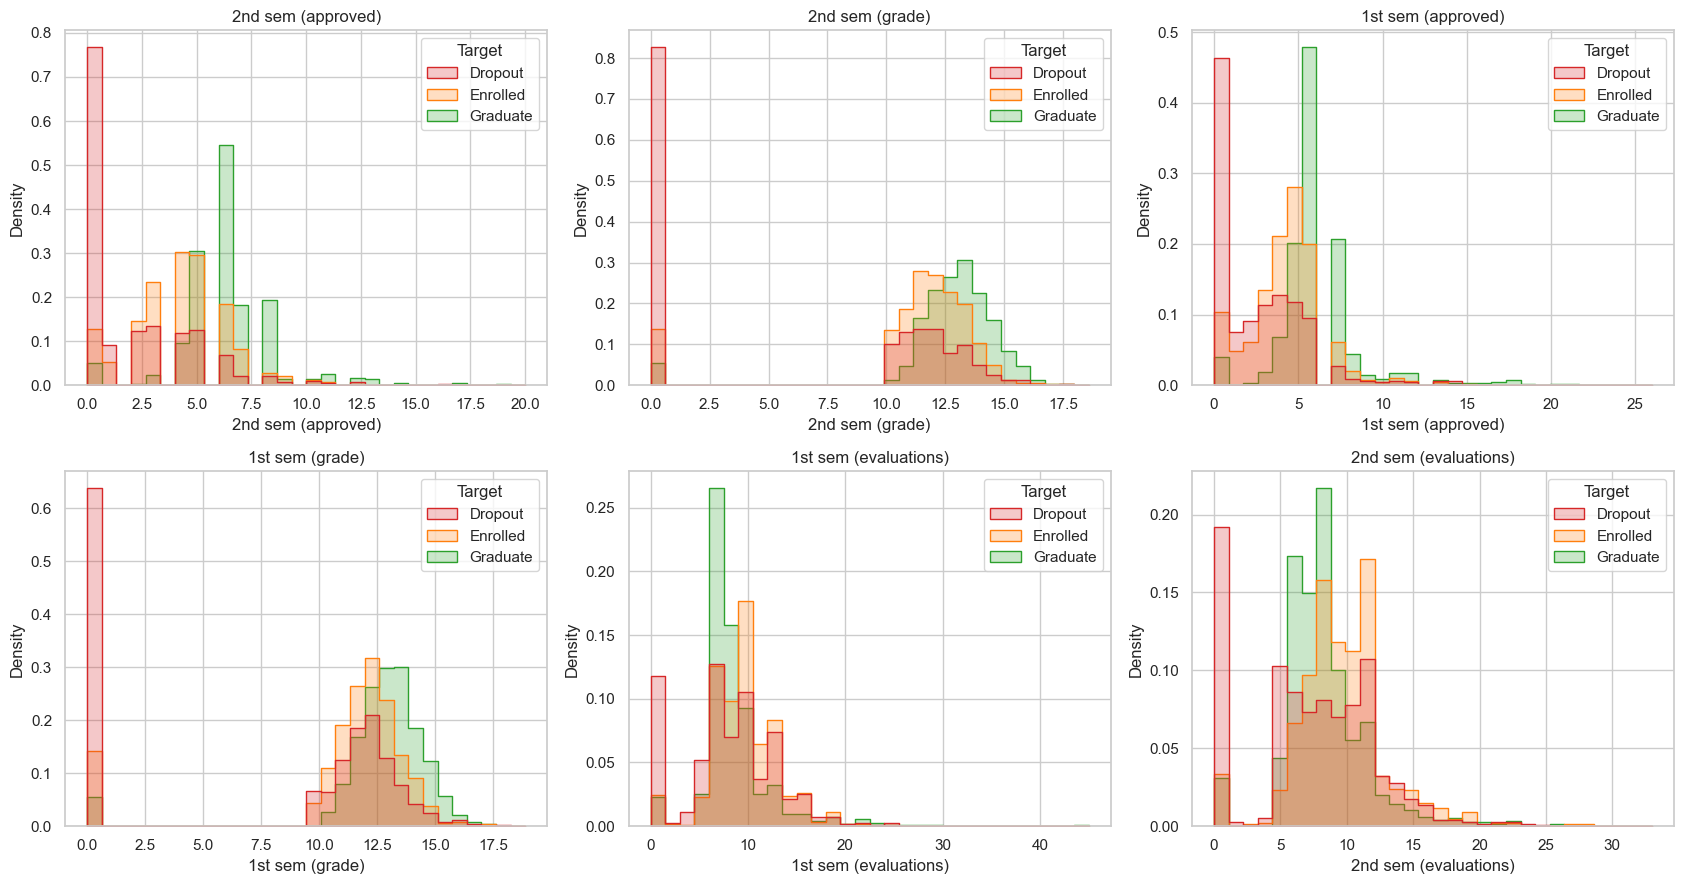

In [10]:
class_palette = {"Dropout": "tab:red", "Enrolled": "tab:orange", "Graduate": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), top_numeric):
    sns.histplot(data=df, x=col, hue=target, hue_order=class_names, palette=class_palette, bins=30,
                 stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

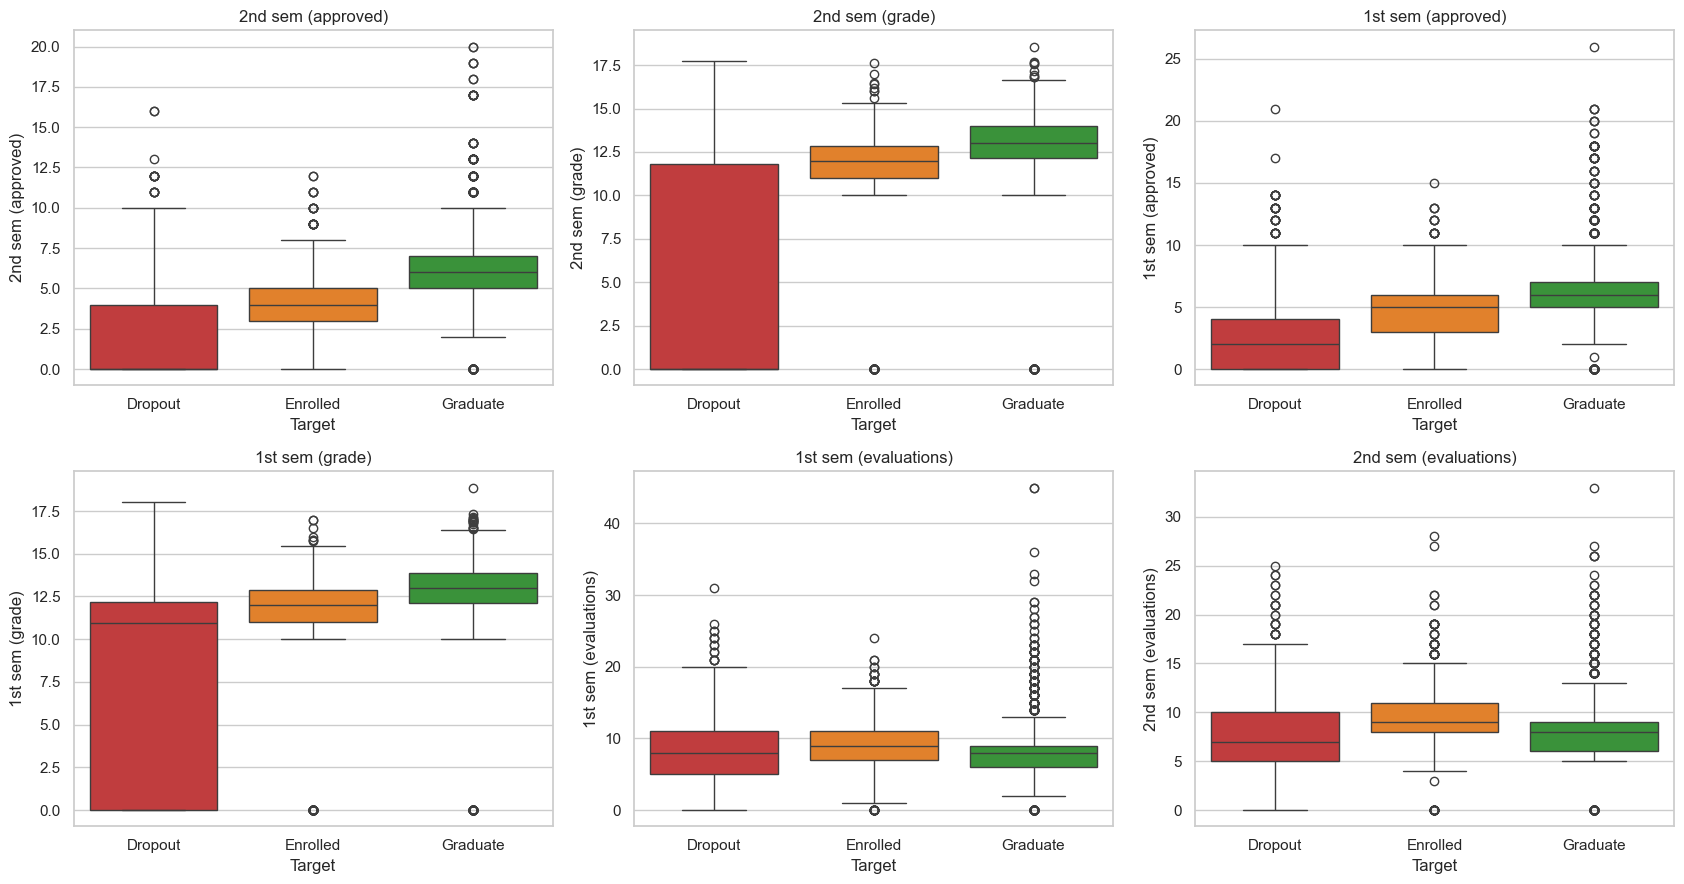

,2nd sem (approved),2nd sem (grade),1st sem (approved),1st sem (grade),1st sem (evaluations),2nd sem (evaluations)
Target,,,,,,
Dropout,0.0,0.0,2.0,10.93,8.0,7.0
Enrolled,4.0,12.0,5.0,12.00,9.0,9.0
Graduate,6.0,13.0,6.0,13.00,8.0,8.0


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), top_numeric):
    sns.boxplot(data=df, x=target, y=col, hue=target, order=class_names, hue_order=class_names,
                palette=class_palette, legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
display(df.groupby(target)[top_numeric].median().reindex(class_names).round(2))

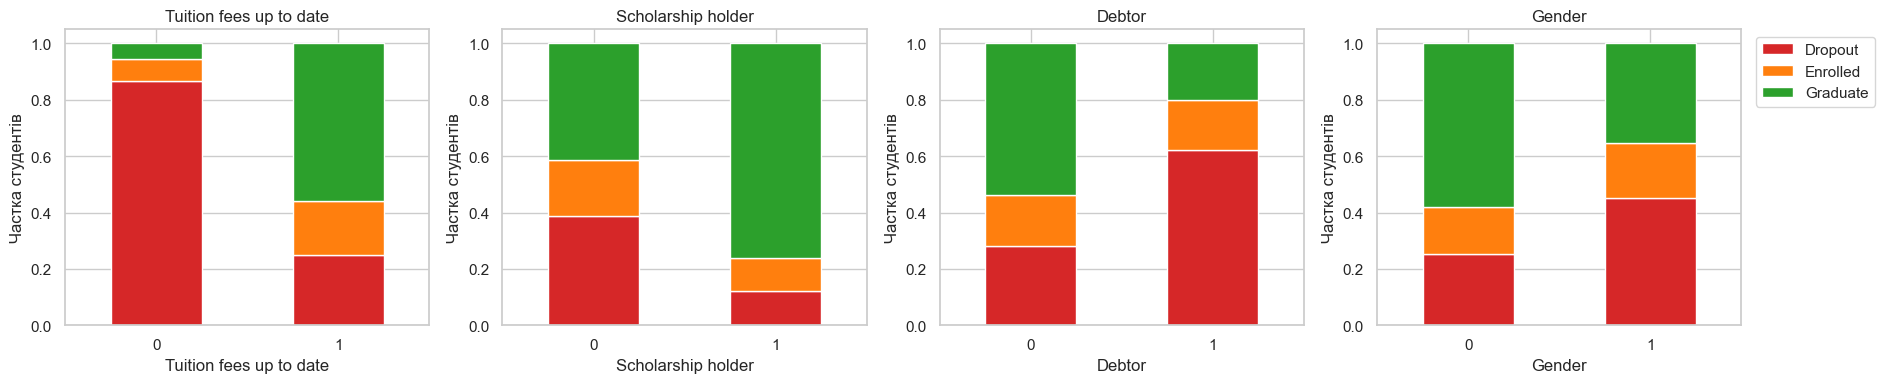

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, col in zip(axes, top_binary):
    pd.crosstab(df[col], df[target], normalize="index")[class_names].plot(
        kind="bar", stacked=True, color=list(class_palette.values()), rot=0, legend=False, ax=ax)
    ax.set_title(col)
    ax.set_ylabel("Частка студентів")
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Гістограми та boxplot-и показують, що за академічними показниками розподіли трьох класів помітно відрізняються. У 51 % відрахованих студентів у другому семестрі немає жодної складеної дисципліни, а середня оцінка дорівнює нулю, тоді як серед випускників таких лише 3 %. Медіана кількості складених дисциплін у другому семестрі становить 0 для Dropout, 4 для Enrolled і 6 для Graduate, а медіана оцінки відповідно 0, 12 і 13. Клас Enrolled розташований між двома іншими й помітно з ними перетинається, тому, найімовірніше, його буде найважче класифікувати. Кількість оцінювань (evaluations) розділяє класи слабше.

Бінарні ознаки теж пов'язані з результатом. Серед студентів із заборгованістю з оплати навчання (`Tuition fees up to date` = 0) відраховано 86.6 %, а серед тих, хто платить вчасно, лише 24.7 %. Серед боржників (`Debtor` = 1) частка відрахованих становить 62.0 % проти 28.3 % серед інших студентів. Стипендіати відраховуються значно рідше (12.2 % проти 38.7 %), а серед чоловіків (`Gender` = 1) частка відрахованих вища, ніж серед жінок (45.1 % проти 25.1 %).

Отже, ознаки справді пов'язані з цільовою змінною (найсильніше це стосується успішності в семестрах і фінансових чинників), тому моделі мають помітно перевершити базовий рівень.

## Підготовка даних до навчання

Дані розділяємо на навчальну та тестову вибірки у пропорції 80/20 (3 539 і 885 студентів) зі стратифікацією, щоб частки класів в обох вибірках були однаковими.

Масштабування потрібне для kNN і SVM, бо ці алгоритми працюють з відстанями між об'єктами, і ознака з великим діапазоном (наприклад, `Admission grade` від 95 до 190) переважала б ознаку з діапазоном від 0 до 20. `StandardScaler` (середнє 0, стандартне відхилення 1) навчаємо лише на навчальній вибірці й застосовуємо до тестової, щоб уникнути витоку даних. Масштабуємо тільки 19 числових ознак, а бінарні та one-hot колонки залишаємо зі значеннями 0 і 1, бо вони вже мають однаковий масштаб. Після стандартизації одиниця в рідкісній one-hot колонці перетворилася б на значення близько 10, і такі колонки переважали б у відстанях. Дерево рішень, Random Forest і AdaBoost нечутливі до масштабу (вони розбивають дані за пороговими значеннями ознак), тому навчаються на немасштабованих даних.

In [13]:
X = data_encoded.drop(columns=target)
y = data_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled, X_test_scaled = X_train.copy(), X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Середні числових ознак після масштабування (train):", X_train_scaled[numeric_cols].mean().abs().max().round(6))
display(pd.DataFrame({"train": y_train.value_counts(normalize=True).sort_index(),
                      "test": y_test.value_counts(normalize=True).sort_index()})
        .rename(index=dict(enumerate(class_names))).round(3))

Train: (3539, 107) | Test: (885, 107)
Середні числових ознак після масштабування (train): 0.0


,train,test
Target,,
Dropout,0.321,0.321
Enrolled,0.179,0.180
Graduate,0.499,0.499


## Навчання моделей

In [14]:
base_models = {
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
}
scaled_models = {"kNN", "SVM"}

base_results = []
for name, model in base_models.items():
    X_tr, X_te = (X_train_scaled, X_test_scaled) if name in scaled_models else (X_train, X_test)
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    base_results.append({
        "Модель": name,
        "Train accuracy": accuracy_score(y_train, model.predict(X_tr)),
        "Test accuracy": accuracy_score(y_test, y_pred),
        "Test F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    })
display(pd.DataFrame(base_results).set_index("Модель").round(4))

,Train accuracy,Test accuracy,Test F1 (macro)
Модель,,,
kNN,0.7974,0.6960,0.6062
Decision Tree,1.0000,0.6870,0.6220
SVM,0.8443,0.7706,0.6927
Random Forest,1.0000,0.7763,0.6849
AdaBoost,0.7785,0.7277,0.6480


Без налаштування гіперпараметрів найкращі результати мають Random Forest (test accuracy 0.776) і SVM (0.771 і найвищий macro F1, 0.693). Decision Tree і Random Forest мають train accuracy 1.0: дерево без обмежень повністю запам'ятовує навчальні дані (перенавчання), тому на тесті одиночне дерево найгірше за accuracy (0.687). Random Forest теж запам'ятовує навчальну вибірку, але усереднення 100 дерев зменшує дисперсію прогнозів, тому на тесті він найкращий. kNN з k = 5 має найнижчий macro F1 (0.606), бо у просторі зі 107 ознак, більшість з яких one-hot, відстані менш інформативні. AdaBoost майже не перенавчається (train accuracy 0.779, test accuracy 0.728), але поступається Random Forest і SVM як за accuracy, так і за macro F1 (0.648).

## Підбір гіперпараметрів

Підбір виконуємо 5-кратною стратифікованою крос-валідацією лише на навчальній вибірці, тестова вибірка в ньому не використовується. Параметри обираємо за macro F1, щоб модель не жертвувала найменшим класом Enrolled.

### 1. kNN: n_neighbors

Перебираємо непарні k від 1 до 51 (непарні значення зменшують імовірність нічиєї при голосуванні сусідів).

Оптимальне n_neighbors: 11
F1 (macro) на крос-валідації: 0.6185


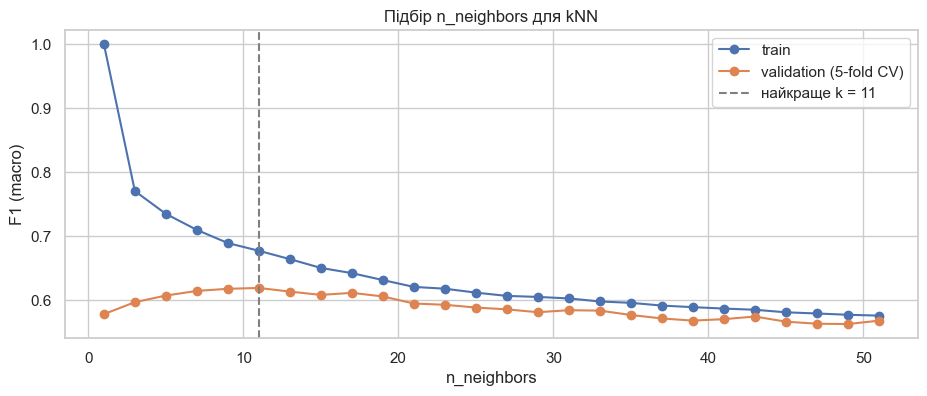

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_values = list(range(1, 52, 2))
knn_grid = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": k_values}, cv=cv,
                        scoring="f1_macro", return_train_score=True, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_k = knn_grid.best_params_["n_neighbors"]
print("Оптимальне n_neighbors:", best_k)
print("F1 (macro) на крос-валідації:", round(knn_grid.best_score_, 4))

plt.figure(figsize=(11, 4))
plt.plot(k_values, knn_grid.cv_results_["mean_train_score"], marker="o", label="train")
plt.plot(k_values, knn_grid.cv_results_["mean_test_score"], marker="o", label="validation (5-fold CV)")
plt.axvline(best_k, color="gray", linestyle="--", label=f"найкраще k = {best_k}")
plt.xlabel("n_neighbors")
plt.ylabel("F1 (macro)")
plt.title("Підбір n_neighbors для kNN")
plt.legend()
plt.show()

При k = 1 модель ідеально відтворює навчальні дані (F1 = 1.0), але на валідації дає один з найгірших результатів, що свідчить про перенавчання. Зі зростанням k метрика на навчальних даних падає, а на валідації спершу зростає й досягає максимуму при k = 11 (macro F1 приблизно 0.62), після чого повільно знижується: занадто велике k згладжує межі між класами, і модель частіше обирає переважний клас Graduate.

### 2. SVM: C та gamma (GridSearchCV)

Оптимальні параметри SVM: {'C': 100, 'gamma': 0.001}
F1 (macro) на крос-валідації: 0.72


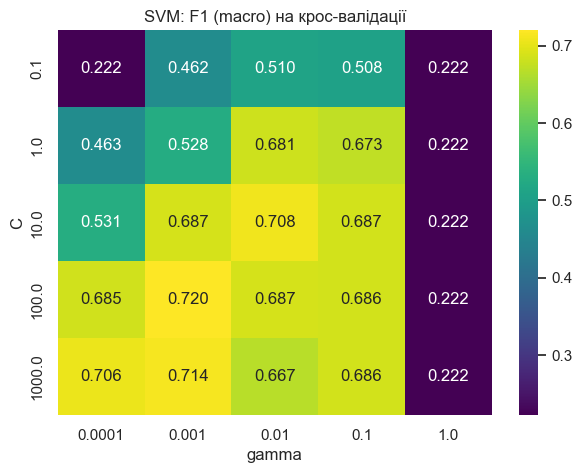

In [16]:
svm_param_grid = {"C": [0.1, 1, 10, 100, 1000], "gamma": [0.0001, 0.001, 0.01, 0.1, 1]}
svm_grid = GridSearchCV(SVC(kernel="rbf"), svm_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
svm_grid.fit(X_train_scaled, y_train)
print("Оптимальні параметри SVM:", svm_grid.best_params_)
print("F1 (macro) на крос-валідації:", round(svm_grid.best_score_, 4))

svm_scores = pd.DataFrame(svm_grid.cv_results_).pivot(index="param_C", columns="param_gamma", values="mean_test_score")
plt.figure(figsize=(7, 5))
sns.heatmap(svm_scores, annot=True, fmt=".3f", cmap="viridis")
plt.title("SVM: F1 (macro) на крос-валідації")
plt.xlabel("gamma")
plt.ylabel("C")
plt.grid(False)
plt.show()

Використовуємо ядро RBF і перебираємо 25 комбінацій параметрів: C із {0.1, 1, 10, 100, 1000} та gamma із {0.0001, 0.001, 0.01, 0.1, 1}. Оптимальними виявилися C = 100 і gamma = 0.001 (macro F1 на крос-валідації 0.720), причому оптимум лежить усередині сітки. Малі значення C і gamma дають надто просту модель, яка недонавчається (F1 від 0.22 до 0.53). Натомість gamma = 1 задає надто вузьке ядро: модель запам'ятовує навчальні точки, а на нових даних вироджується до прогнозу одного класу (F1 = 0.222, як у базової моделі).

### 3. Decision Tree

In [17]:
dt_param_grid = {"max_depth": [3, 5, 7, 10, 15, None], "min_samples_leaf": [1, 5, 10, 20, 50]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_param_grid,
                       cv=cv, scoring="f1_macro", n_jobs=-1)
dt_grid.fit(X_train, y_train)
print("Оптимальні параметри Decision Tree:", dt_grid.best_params_)
print("F1 (macro) на крос-валідації:", round(dt_grid.best_score_, 4))

Оптимальні параметри Decision Tree: {'max_depth': 10, 'min_samples_leaf': 50}
F1 (macro) на крос-валідації: 0.6759


Додатково підбираємо параметри дерева рішень: обмеження глибини (`max_depth`) і мінімальної кількості об'єктів у листі (`min_samples_leaf`) зменшує перенавчання. Оптимальні значення: `max_depth` = 10, `min_samples_leaf` = 50 (macro F1 на крос-валідації 0.676). У результаті train accuracy падає з 1.0 до 0.77, а test accuracy зростає з 0.687 до 0.745 (див. порівняння моделей нижче).

## Порівняння та оцінювання моделей

Порівнюємо налаштовані kNN, Decision Tree і SVM, а також Random Forest і AdaBoost зі стандартними параметрами. Для орієнтиру додаємо базову модель `DummyClassifier`, яка завжди передбачає найчастіший клас (Graduate): будь-яка корисна модель має бути помітно кращою за неї. Таблицю відсортовано за macro F1.

In [18]:
final_models = {
    "Baseline (most frequent)": (DummyClassifier(strategy="most_frequent"), X_train, X_test),
    f"kNN (k={best_k})": (knn_grid.best_estimator_, X_train_scaled, X_test_scaled),
    "Decision Tree (tuned)": (dt_grid.best_estimator_, X_train, X_test),
    "SVM (tuned)": (svm_grid.best_estimator_, X_train_scaled, X_test_scaled),
    "Random Forest": (base_models["Random Forest"], X_train, X_test),
    "AdaBoost": (base_models["AdaBoost"], X_train, X_test),
}

results = []
predictions = {}
for name, (model, X_tr, X_te) in final_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    predictions[name] = y_pred
    results.append({
        "Модель": name,
        "Train accuracy": accuracy_score(y_train, model.predict(X_tr)),
        "Test accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    })
results_df = pd.DataFrame(results).set_index("Модель").sort_values("F1 (macro)", ascending=False)
display(results_df.round(4))

,Train accuracy,Test accuracy,Precision (macro),Recall (macro),F1 (macro)
Модель,,,,,
SVM (tuned),0.8175,0.7627,0.7044,0.6813,0.6890
Random Forest,1.0000,0.7763,0.7296,0.6758,0.6849
Decision Tree (tuned),0.7697,0.7446,0.6833,0.6494,0.6545
AdaBoost,0.7785,0.7277,0.6528,0.6455,0.6480
kNN (k=11),0.7615,0.7062,0.6574,0.5970,0.6055
Baseline (most frequent),0.4993,0.4994,0.1665,0.3333,0.2221


### Classification report і confusion matrix

In [19]:
for name, y_pred in predictions.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred), "\n")

Baseline (most frequent)
              precision    recall  f1-score   support

     Dropout     0.0000    0.0000    0.0000       284
    Enrolled     0.0000    0.0000    0.0000       159
    Graduate     0.4994    1.0000    0.6662       442

    accuracy                         0.4994       885
   macro avg     0.1665    0.3333    0.2221       885
weighted avg     0.2494    0.4994    0.3327       885

Confusion matrix:
[[  0   0 284]
 [  0   0 159]
 [  0   0 442]] 

kNN (k=11)
              precision    recall  f1-score   support

     Dropout     0.7773    0.6268    0.6940       284
    Enrolled     0.4872    0.2390    0.3207       159
    Graduate     0.7076    0.9253    0.8020       442

    accuracy                         0.7062       885
   macro avg     0.6574    0.5970    0.6055       885
weighted avg     0.6904    0.7062    0.6808       885

Confusion matrix:
[[178  27  79]
 [ 31  38  90]
 [ 20  13 409]] 

Decision Tree (tuned)
              precision    recall  f1-score   su

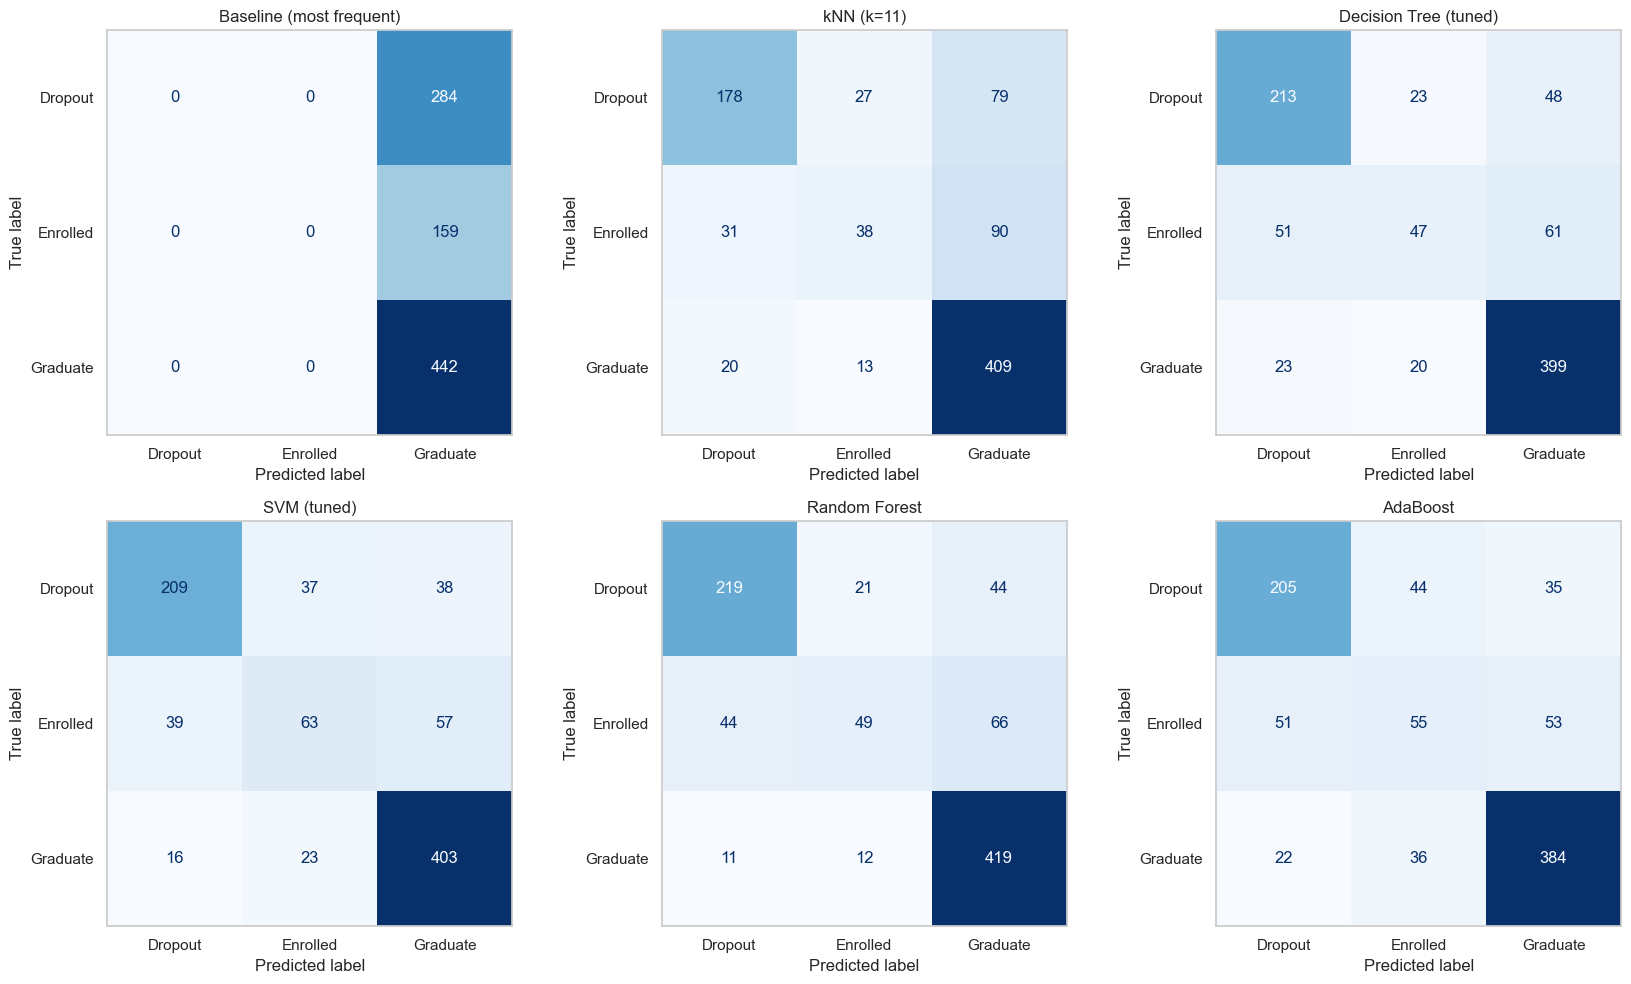

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=class_names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

Аналіз classification report і confusion matrix:

- Graduate розпізнається найкраще: recall від 0.87 до 0.95 у всіх моделях, крім базової. У більшості випускників високі показники в обох семестрах.
- Dropout розпізнається добре: F1 від 0.69 до 0.78, найкраще в Random Forest (0.785) і SVM (0.763).
- Enrolled є найскладнішим класом, його recall становить лише від 0.24 до 0.40. За успішністю такі студенти перебувають між відрахованими та випускниками, тому моделі найчастіше плутають їх із Graduate: наприклад, SVM відніс 57 із 159 студентів Enrolled до Graduate і 39 до Dropout. Найкраще з цим класом справляється SVM (recall 0.40, F1 0.447 проти 0.407 у Random Forest).
- Базова модель усіх студентів відносить до Graduate: її accuracy 0.499, але macro F1 лише 0.222. Тому сама accuracy тут недостатня метрика.

### Порівняння моделей

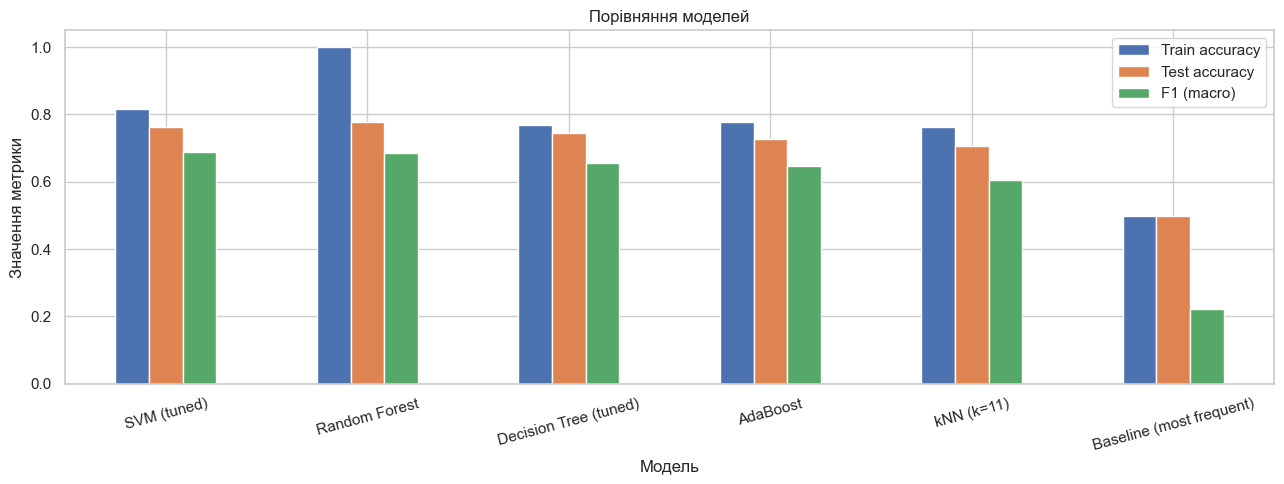

Найкраща модель за F1 (macro): SVM (tuned)
Train accuracy       0.8175
Test accuracy        0.7627
Precision (macro)    0.7044
Recall (macro)       0.6813
F1 (macro)           0.6890
Name: SVM (tuned), dtype: float64


In [21]:
ax = results_df[["Train accuracy", "Test accuracy", "F1 (macro)"]].plot(kind="bar", figsize=(13, 5), rot=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Значення метрики")
ax.set_title("Порівняння моделей")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

best_name = results_df.drop(index="Baseline (most frequent)")["F1 (macro)"].idxmax()
print("Найкраща модель за F1 (macro):", best_name)
print(results_df.loc[best_name].round(4))

### Важливість ознак (Random Forest)

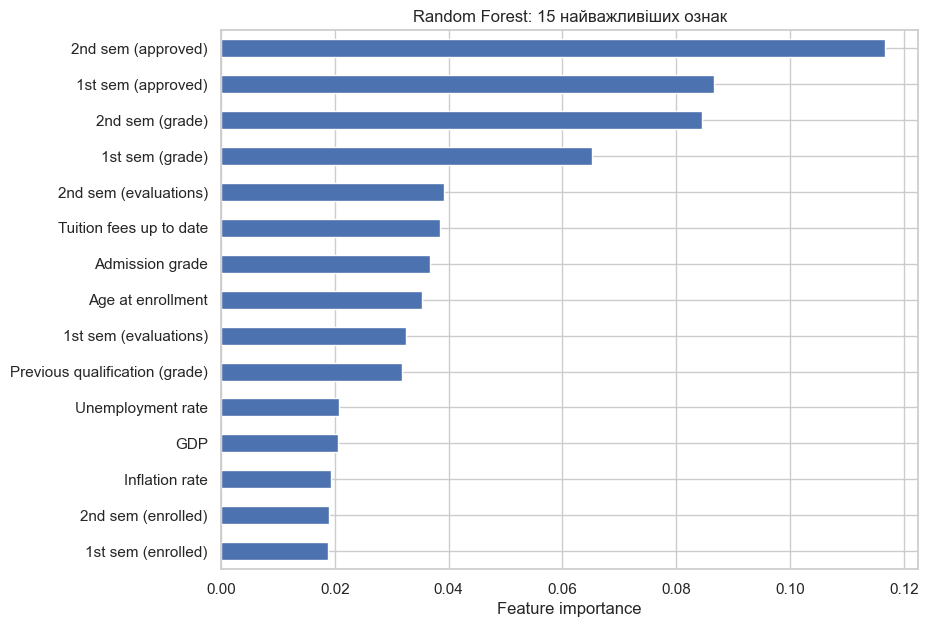

In [22]:
importances = pd.Series(base_models["Random Forest"].feature_importances_, index=X.columns)
importances.sort_values().tail(15).plot(kind="barh", figsize=(9, 7))
plt.title("Random Forest: 15 найважливіших ознак")
plt.xlabel("Feature importance")
plt.show()

Random Forest вважає найважливішими ті самі ознаки, що й mutual information: кількість складених дисциплін і середні оцінки за обидва семестри. Далі йдуть кількість оцінювань, своєчасна оплата навчання, вступна оцінка й вік.

### Врахування дисбалансу класів

In [23]:
balanced_svm = SVC(kernel="rbf", class_weight="balanced", **svm_grid.best_params_)
balanced_svm.fit(X_train_scaled, y_train)
print(classification_report(y_test, balanced_svm.predict(X_test_scaled), target_names=class_names, digits=4))

              precision    recall  f1-score   support

     Dropout     0.8496    0.6761    0.7529       284
    Enrolled     0.4344    0.6667    0.5261       159
    Graduate     0.8675    0.8145    0.8401       442

    accuracy                         0.7435       885
   macro avg     0.7172    0.7191    0.7064       885
weighted avg     0.7839    0.7435    0.7557       885



Цей додатковий експеримент перевіряє, чи допоможе параметр `class_weight="balanced"` краще розпізнавати клас Enrolled. SVM з тими самими C і gamma, але з вагами класів, обернено пропорційними їхній частоті, підвищує recall для Enrolled з 0.40 до 0.67, а macro F1 з 0.689 до 0.706. Водночас accuracy знижується з 0.763 до 0.744, бо модель частіше відносить студентів до класу Enrolled і через це частіше помиляється на інших класах.

## Висновки

- Усі моделі значно перевершують базовий рівень (accuracy 0.499, macro F1 0.222), тобто ознаки справді містять інформацію про результат навчання.
- Найкращий результат за основною метрикою (macro F1) показала SVM з RBF-ядром (C = 100, gamma = 0.001): macro F1 = 0.689, accuracy = 0.763. Дуже близько до неї Random Forest: він має найвищу accuracy (0.776) і найкраще розпізнає Dropout, але macro F1 трохи нижчий (0.685) через слабше розпізнавання Enrolled. Далі йдуть Decision Tree (0.655), AdaBoost (0.648) і kNN (0.606).
- Чому SVM підходить для цих даних: після one-hot кодування маємо 107 ознак, і RBF-SVM добре працює в такому просторі, будуючи нелінійну межу з максимальним зазором. Регуляризація через C стримує перенавчання: розрив train/test становить 0.82 проти 0.76, значно менше, ніж у дерев. Завдяки цьому SVM краще за інших знаходить проміжний клас Enrolled, що й дає найвищий macro F1.
- Різниця між SVM і Random Forest (0.004 за macro F1 і 1.4 відсоткового пункту за accuracy) менша за статистичну похибку оцінки на 885 тестових об'єктах (приблизно 2.8 відсоткового пункту для accuracy), тому фактично ці моделі рівноцінні. З тієї ж причини SVM зі стандартними параметрами на тестовій вибірці виявилася навіть трохи кращою за налаштовану (accuracy 0.771 проти 0.763), хоча на 5-кратній крос-валідації налаштовані параметри кращі (macro F1 0.720 проти 0.690). Крос-валідація дає надійнішу оцінку, ніж одне розбиття на навчальну й тестову вибірки.
- SVM і Random Forest стабільно кращі за одиночне дерево та kNN: одне дерево схильне до перенавчання, а kNN страждає від великої кількості розріджених one-hot ознак. AdaBoost зі стандартними параметрами (50 дерев глибиною 1) виявився навіть трохи гіршим за налаштоване дерево рішень.
- Найважливішими ознаками (і за mutual information, і за Random Forest) є кількість складених дисциплін і оцінки за 1-й та 2-й семестри, своєчасна оплата навчання, вступна оцінка й вік. Отже, ризик відрахування найкраще видно за успішністю в першому навчальному році.
- Можливе покращення: врахування дисбалансу класів (`class_weight="balanced"`) підвищує recall для Enrolled з 0.40 до 0.67 і macro F1 до 0.706 ціною зниження accuracy до 0.744. Це корисно, якщо потрібно якомога раніше виявляти студентів «групи ризику».